¡Hola Dante! Espero estés bien.

Mi nombre es **Gina Buvoli**. Un gusto conocerte, seré tu revisora en este proyecto.

A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:

Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.

Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más precisa, junto con algunos ejemplos prácticos. También estoy abierta a responder cualquier duda que tengas.

Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis. Continúa aplicando estas buenas prácticas en futuras secciones.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>Atención ⚠️</b><br>
El código es correcto, pero hay una recomendación de mejora. No bloquea la aprobación, pero vale la pena ajustarlo.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>A resolver 🔴</b><br>
Aquí hay un error que es necesario corregir para aprobar. Por favor revisa este punto antes de volver a enviar.
</div>

---

En cada revisión recibirás un **Comentario General** que resume los aspectos positivos, las áreas de mejora y los próximos pasos.

También puedes responderme copiando el siguiente bloque si tienes alguna duda:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante [#° iteración]</b> <a class="tocSkip"></a>

Aquí puedes escribir tu respuesta o pregunta.
</div>

**¡Empecemos!** 🚀


<div class="alert alert-block alert-success">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a>

¡Hola Dante!

Muy buen trabajo en esta primera entrega. El notebook está organizado, carga correctamente los tres datasets, identifica los principales problemas de calidad de datos, limpia los sentinels más importantes, construye métricas por usuario, genera visualizaciones, segmenta clientes y presenta un análisis ejecutivo con recomendaciones accionables. También dejaste el repositorio de GitHub con README y notebook, lo cual cumple con el entregable de reproducibilidad. El proyecto queda **aprobado**. 

Te dejé algunas recomendaciones menores para fortalecer la interpretación visual y cuidar la clasificación de usuarios con valores ausentes en las métricas de uso. No bloquean la aprobación, pero pueden ayudarte a mejorar la claridad del análisis en próximos proyectos.

Saludos,  
Gina Buvoli
</div>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [106]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [107]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [108]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [109]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [110]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [111]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [112]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [113]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [114]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
Muy buen inicio. Importaste las librerías necesarias, cargaste correctamente los tres datasets y revisaste su estructura con `.head()`, `.shape` e `.info()`. Esta exploración inicial permite entender el tamaño, los tipos de datos y los valores faltantes antes de avanzar a la limpieza.
</div>

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [115]:

# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [116]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 

 Recomendaciones de dataset users:
- city (11.72% nulos): Dejar los valores como nulos, porque no se puede imputar una ciudad desconocida sin información adicional.
- churn_date (88.35% nulos): Mantener como nulos, por que este no es un verdadero valor faltante, solo indica que el cliente no ha cancelado, los nulos representan clientes activos.
Recomendaciones de dataset usage:
- date (0.12% nulos): Eliminar estas filas o imputar con fecha cercana, por que es una proporción mínima (<5%). La eliminación no afecta significativamente el análisis.
- duration (55.19% nulos): Dejar los valores nulos como están.Por que los valores nulos en duration corresponden a los mensajes (type='text'), que no tienen duración de llamada.
- length (44.74% nulos): Dejar los valores nulos como están, por que los valores nulos en length corresponden a las llamadas (type='call'), que no tienen longitud de mensaje.

Decisión: Si se confirma MAR, se DEJAN como nulos porque representan ausencia lógica del dato, no error de captura.
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [117]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


La columna user_id: Es un identificador secuencial (10000–13999) y no tiene valores problemáticos, no se analiza estadísticamente.

La columna age: Contiene un valor inválido extremo (min = -999) que actúa como un sentinel para datos faltantes y distorsiona la media real.

In [118]:

# explorar columnas numéricas de usage
usage.describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


Las columnas id y user_id son identificadores (1–40,000 y 10,000–13,999 respectivamente), no se analizan estadísticamente.
- duration: rango de 0 a 120 minutos, valores razonables para llamadas. El count de 17,924 vs 40,000 filas totales confirma que los NaN corresponden a registros que no son llamadas.
- length: rango de 0 a 1,490 caracteres, razonable para mensajes. El count de 22,104 vs 40,000 filas confirma que los NaN corresponden a registros que no son mensajes.

In [119]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- Valores únicos en {col} ---")
    print(users[col].unique())
    print()


--- Valores únicos en city ---
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

--- Valores únicos en plan ---
['Basico' 'Premium']



- city contiene el sentinel "?" además de nulos reales (nan), ambos representan ciudad desconocida y se reemplazarán por pd.NA en el paso de limpieza. Los valores válidos son: Medellín, CDMX, Bogotá, GDL, MTY y Cali.
- plan solo contiene 'Basico' y 'Premium', sin valores inválidos, no requiere acción.

In [120]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64


- type solo contiene `'text'` (22,092) y `'call'` (17,908), sin valores inválidos. Esto explica los NaN en `duration` (ausente en mensajes) y `length` (ausente en llamadas).

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

age: Tiene valores -999 que no son edades reales. Se reemplazarán con la mediana.
city: Tiene "?" como ciudad desconocida. Se convertirá a nulo.
duration y length: Sus nulos son esperados según el tipo de evento, no son errores.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [121]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [122]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [123]:

# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En reg_date aparecen años válidos (2022, 2023, 2024) y 40 registros con año 2026. Como el análisis considera datos hasta 2024, esas fechas futuras son imposibles y se marcarán como nulos en el paso de limpieza.

In [124]:
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date` todos los registros corresponden al año 2024, dentro del rango válido del análisis. No se detectaron fechas imposibles, por lo que no requiere acción adicional.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
  
reg_date en users: contiene 40 registros con año 2026, una fecha futura imposible considerando que el análisis cubre datos hasta 2024. Se marcarán como nulos.
date en usage: todos los registros corresponden a 2024, sin fechas imposibles. No requiere acción.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
Buen trabajo en la identificación de problemas de calidad. Detectaste correctamente los nulos, el sentinel `-999` en `age`, el valor `"?"` en `city` y las fechas futuras en `reg_date`. Además, validaste que `plan` y `type` contienen categorías esperadas, por lo que no requieren limpieza adicional. Para el alcance de esta sección, la revisión de `plans` no necesita una exploración adicional porque es un dataset pequeño de referencia y no presenta variables problemáticas para esta etapa del análisis.
</div>

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [125]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [126]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [127]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts().sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [128]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [129]:
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

duration es nulo en el 99.9% de los mensajes y en ninguna llamada, porque la duración solo aplica a llamadas. length es nulo en el 99.9% de las llamadas y en ningún mensaje, porque la longitud solo aplica a mensajes. Ambas son MAR: la ausencia depende del tipo de evento, no es un error. Se dejan como nulos.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
Muy buena limpieza. Reemplazaste `-999` en `age` usando la mediana calculada sin el sentinel, convertiste `"?"` en `city` a valores nulos y marcaste como `NaT` las fechas futuras. También verificaste correctamente que los nulos de `duration` y `length` dependen del tipo de evento, por lo que tiene sentido mantenerlos como nulos lógicos.
</div>

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [130]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)  # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)  # conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [131]:
# Renombrar columnas, Las columnas ya están nombradas correctamente y no se necesita cambiarles el nombre otra vez.

# observar resultado
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [132]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [133]:
# Resumen estadístico de las columnas numéricas

cols_num = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[cols_num].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [134]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
La agregación por usuario está correctamente construida. Creaste métricas claras para cantidad de mensajes, cantidad de llamadas y minutos totales de llamada, y luego las integraste con la tabla de usuarios usando un `merge` apropiado. El uso de `.describe()` y `value_counts(normalize=True)` también ayuda a entender la distribución general de las variables y de los planes.
</div>

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

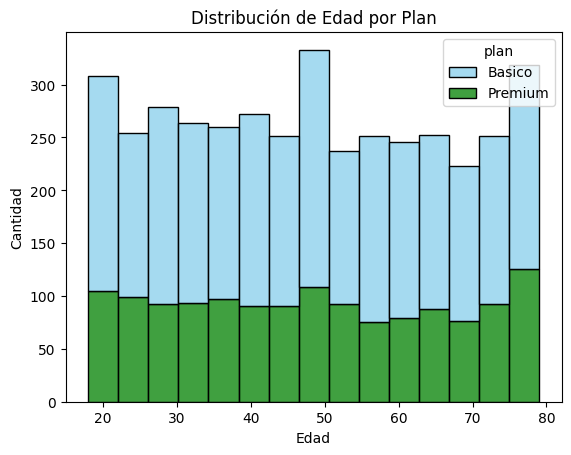

In [135]:
sns.histplot(data=user_profile, x='age', hue='plan', bins=15,
             palette=['skyblue', 'green'], multiple='stack')
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.show()

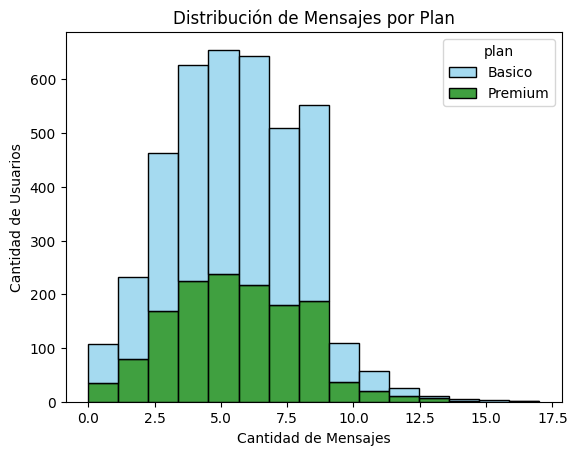

In [136]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=15,
             palette=['skyblue', 'green'], multiple='stack')
plt.title('Distribución de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

Insights — Mensajes:

Distribución sesgada a la derecha: la mayoría de usuarios envía entre 3 y 8 mensajes, con pocos usuarios enviando cantidades muy altas (12 o más).
Los usuarios Básico superan a los Premium en todos los rangos, consistente con el dominio de ese plan en la base de clientes.
No existe un patrón claro entre el plan y la cantidad de mensajes enviados — ambos planes se comportan de forma similar.

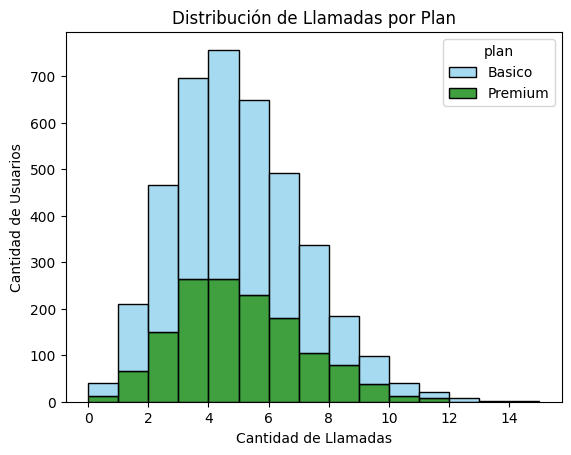

In [137]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=15,
             palette=['skyblue', 'green'], multiple='stack')
plt.title('Distribución de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

Insights — Llamadas:

Distribución sesgada a la derecha: la mayoría de usuarios realiza entre 3 y 7 llamadas, con pocos usuarios haciendo más de 10.
Los usuarios Básico superan a los Premium en todos los rangos, consistente con el dominio de ese plan.
No existe un patrón claro entre el plan y la cantidad de llamadas — ambos planes se comportan de forma similar.

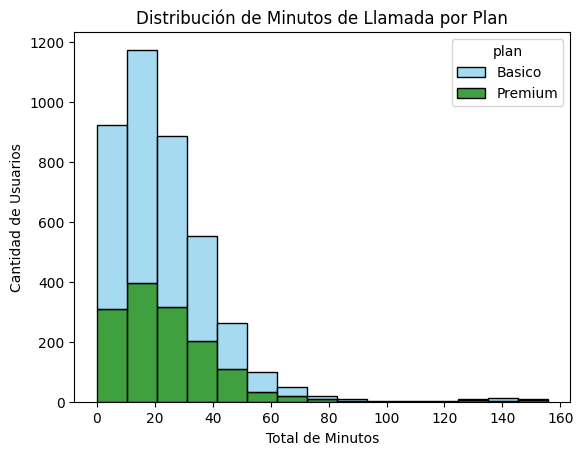

In [138]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=15,
             palette=['skyblue', 'green'], multiple='stack')
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Cantidad de Usuarios')
plt.show()

 Insights — Minutos de llamada:

Distribución sesgada a la derecha: la mayoría de usuarios acumula entre 0 y 40 minutos totales, con muy pocos usuarios superando los 80 minutos.
Los usuarios Básico superan a los Premium en todos los rangos, consistente con el dominio de ese plan.
No existe un patrón claro entre el plan y los minutos acumulados — ambos planes se comportan de forma similar.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

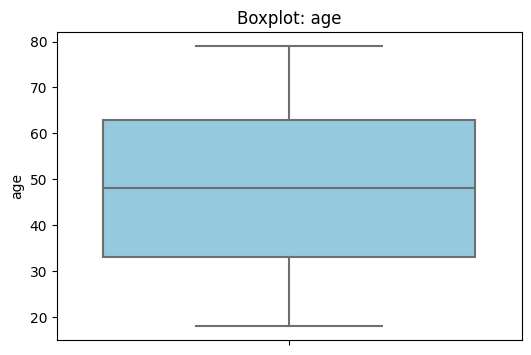

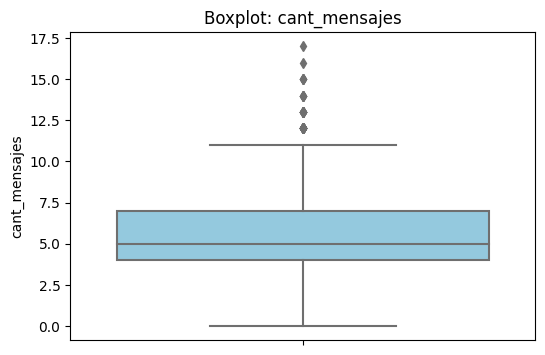

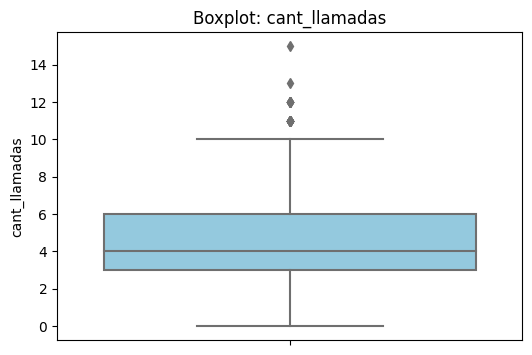

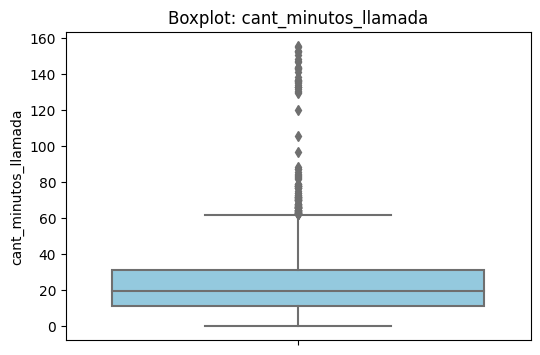

In [139]:
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=user_profile, y=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()

Insights:

Age: no presenta outliers — la caja y los bigotes cubren todo el rango (18 a 79 años) sin puntos sueltos.

cant_mensajes: presenta outliers superiores — varios puntos por encima del bigote superior (~11), llegando hasta 17 mensajes.

cant_llamadas: presenta outliers superiores — puntos por encima de ~10 llamadas, hasta 15.

cant_minutos_llamada: presenta outliers superiores — el gráfico muestra muchos puntos por encima de ~60 minutos, con valores que llegan hasta ~156.

In [140]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f'{col}: límite superior = {limite_superior:.2f}')

cant_mensajes: límite superior = 11.50
cant_llamadas: límite superior = 10.50
cant_minutos_llamada: límite superior = 61.86


In [141]:


# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()



,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


Insights:

cant_mensajes: mantener los outliers. El máximo (17) supera el límite superior (11.5), pero es un valor plausible de un cliente que envía muchos mensajes — no hay evidencia de que sea un error de captura, solo uso intenso.

cant_llamadas: mantener los outliers. El máximo (15) supera el límite superior (10.5) por un margen pequeño; sigue siendo un número de llamadas razonable para un usuario activo.

cant_minutos_llamada: mantener los outliers. El máximo (~155.7 min) supera bastante el límite superior (61.86), pero equivale a acumular poco más de 2.5 horas de llamadas — factible para un cliente que usa mucho el servicio, no un dato imposible.

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
Las visualizaciones y el análisis IQR están bien planteados: usaste histogramas con comparación por plan, boxplots y límites superiores para revisar posibles outliers. Como mejora menor, agrega también un insight explícito para el histograma de `age`, igual que hiciste con mensajes, llamadas y minutos. Además, recuerda que cuando un plan tiene más usuarios que otro, comparar solo conteos absolutos puede hacer que el plan mayoritario parezca dominar todos los rangos; en esos casos, conviene aclararlo en la interpretación.
</div>

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [142]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [143]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [144]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [145]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

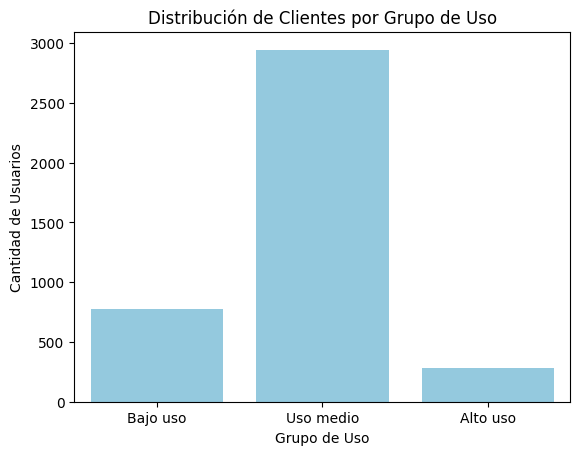

In [146]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], color='skyblue')
plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

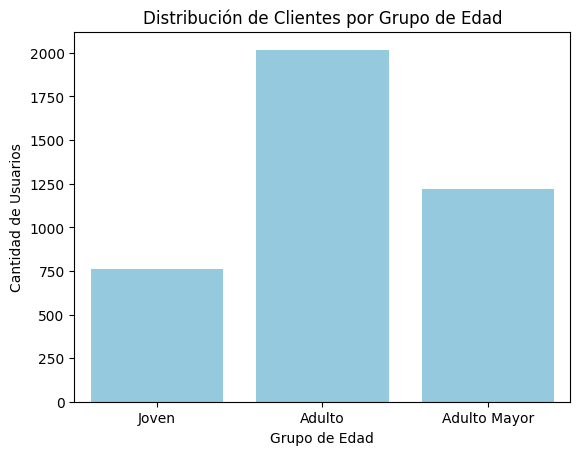

In [147]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], color='skyblue')
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
La segmentación por uso y edad cumple con la lógica solicitada y las visualizaciones tienen títulos y etiquetas claras. Usar funciones propias en lugar de `np.where` es una alternativa válida y legible. Como recomendación, revisa qué ocurre con usuarios que no tengan registros de uso después del `merge`: si `cant_llamadas` o `cant_mensajes` quedan en `NaN`, las comparaciones lógicas pueden enviarlos al grupo de “Alto uso” por el `else`. Antes de segmentar, podrías decidir si esos valores deben tratarse como 0 o como una categoría aparte.
</div>


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo


⚠️ **Problemas detectados en los datos**

- La columna age contenía el sentinel -999 en 55 registros (1.38% de los 4,000 usuarios), un valor imposible que distorsionaba la media.
- La columna city tenía el sentinel "?" en 96 registros (2.4%), tratado como ciudad desconocida.
- reg_date incluía 40 registros (1.0%) con año 2026, fechas futuras imposibles dado que el análisis cubre hasta 2024.
- En usage, duration es nulo en 55.2% de las filas y length en 44.7%, pero esto es esperado (MAR): duration solo aplica a llamadas y length solo a mensajes, no representa un error.


🔍 **Segmentos por Edad**

- Adulto es el segmento dominante con 50.4% de los usuarios (2,018), seguido de Adulto Mayor con 30.6% (1,222) y Joven con 19.0% (760).
- Al comparar el nivel de uso (bajo, medio, alto) dentro de cada grupo de edad, los porcentajes son casi iguales en los tres grupos (por ejemplo, el "alto uso" representa 7.6% de los Adultos, 6.1% de los Adultos Mayores y 6.7% de los Jóvenes). Esto significa que la edad de un cliente no influye realmente en cuánto usa el servicio.

📊 **Segmentos por Nivel de Uso**

- Uso medio es el segmento más grande con 73.6% de los usuarios (2,943), seguido de Bajo uso con 19.4% (778) y Alto uso con solo 7.0% (279).
- El grupo de Alto uso consume en promedio 9.6 mensajes, 5.9 llamadas y 30.1 minutos de llamada, más del doble que el grupo de Bajo uso (3.1 mensajes, 2.8 llamadas y 14.9 minutos).
- El grupo de Alto uso también tiene la tasa de cancelación (churn) más alta: 14.0%, frente a ~11.5% en Uso medio y Bajo uso.

➡️ Esto sugiere que el nivel de uso, no la edad, es la variable que realmente diferencia el comportamiento de los clientes. Además, los clientes más activos son los que más cancelan, lo que podría indicar que el plan actual no está satisfaciendo sus necesidades (por ejemplo, cobros por excedente) y representan una oportunidad clara para un plan diseñado a su medida.

💡 **Recomendaciones**

- Crear un plan "Alto Consumo / Ilimitado" dirigido al 7.0% de clientes de Alto uso: consumen más del doble que el resto (9.6 mensajes, 5.9 llamadas, 30.1 min en promedio) y tienen la tasa de cancelación más alta (14.0%), lo que sugiere que el plan actual no cubre sus necesidades y podrían estar pagando cargos por excedente.
- Revisar el plan Básico: concentra el 60.6% de los outliers de minutos de llamada (clientes que superan ampliamente el uso normal), por lo que es candidato a incluir un paquete de minutos más generoso o a impulsar la migración de esos usuarios hacia Premium.
- No usar la edad como criterio de segmentación comercial, ya que el comportamiento de uso es prácticamente idéntico entre Jóvenes, Adultos y Adultos Mayores (no vas a lograr nada distinto que si se la mandas a cualquier otro cliente); enfocar la segmentación y las campañas en el nivel de uso real del cliente.
- Aquí la versión con esa aclaración incluida:
- Priorizar la retención del segmento de Alto uso con acciones específicas (por ejemplo, descuentos por permanencia o un upgrade proactivo de plan, es decir, ofrecerle a estos clientes cambiarse a un plan superior antes de que ellos lo pidan o tengan problemas, en vez de esperar a que se quejen o estén a punto de cancelar), ya que es el segmento más valioso en volumen de consumo: un cliente típico de Alto uso habla por teléfono el doble de minutos que uno de Bajo uso (30.15 minutos de llamada en promedio, frente a 14.92), y además presenta la tasa de cancelación más alta (14.0%, frente a ~11.5% en Uso medio y Bajo uso).

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
El análisis ejecutivo está bien desarrollado. Incluyes problemas de calidad, porcentajes, segmentos por edad y uso, posibles implicaciones de negocio y recomendaciones accionables. Además, conectas los hallazgos con decisiones comerciales, especialmente en el segmento de alto uso y su posible relación con churn. Buen trabajo traduciendo el análisis técnico a lenguaje de negocio.
</div>

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: LINK a tu repo aquí

https://github.com/dantemota12/connectatel-customer-behavior-analysis

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
El entregable de GitHub cumple: el repositorio está disponible, contiene el notebook y cuenta con un README que explica el objetivo, los datasets, el flujo de análisis y cómo ejecutar el proyecto. Esto hace que el trabajo sea más fácil de revisar y reproducir.
</div>